# YIG strip: from a physical stripline field to a dispersion map

This example excites a rectangular YIG strip with the analytic field of an infinitely long, thin current strip. It first asks MuMax3 for the simulation geometry, uses that OVF file as the template for a physically normalized antenna field, and then runs a broadband simulation. The final sections compare spectra calculated with and without timestamp dejittering and transform the complex spectrum along the strip to obtain an RMS $f$-$k_x$ map.

The strip current is along $+y$, its width is $w$, and its centre is at $(x,z)=(x_c,z_a)$. In the formulas below, $x$ denotes the antenna-relative coordinate $x_\mathrm{global}-x_c$. Integrating the Biot--Savart field of a uniform sheet current $I/w$ gives

$$
B_x=\frac{\mu_0I}{2\pi w}\left[\tan^{-1}\!\frac{x+w/2}{d}-\tan^{-1}\!\frac{x-w/2}{d}\right],\qquad
B_z=\frac{\mu_0I}{4\pi w}\ln\!\frac{d^2+(x-w/2)^2}{d^2+(x+w/2)^2},
$$

where $d=z-z_a$ and $B_y=0$. At $r\gg w$, these expressions reduce to $|B|=\mu_0I/(2\pi r)$, the field of an infinite thin wire. That far-field match supplies the physical prefactor missing from the dimensionless MuMax expression.


## Set up a disposable workspace and locate the tools

The notebook location is discovered independently of the directory from which Jupyter was launched. Set `MUMAX3` or `OVF_BATCHFFT` in the environment if either executable is not on `PATH`.


In [19]:
%pip install -q ipynbname matplotlib numpy scipy

import os
import re
import shutil
import subprocess
import tempfile
from pathlib import Path

import ipynbname
import matplotlib.pyplot as plt
import numpy as np
import ovftoolkit as ovf
from scipy.constants import mu_0

if "work_dir" in globals():
    shutil.rmtree(work_dir, ignore_errors=True)

notebook_directory = ipynbname.path().parent
template_file = notebook_directory / "yig-strip.mx3.in"
work_dir = Path(tempfile.mkdtemp(prefix="ovftoolkit-yig-strip-"))

def find_program(environment_name, executable):
    configured = os.environ.get(environment_name)
    found = configured or shutil.which(executable)
    if found is None:
        raise RuntimeError(
            f"{executable} was not found; put it on PATH or set {environment_name}"
        )
    return Path(found).resolve()

mumax3 = find_program("MUMAX3", "mumax3")
batchfft = find_program("OVF_BATCHFFT", "ovf-batchfft")
print(f"Temporary workspace: {work_dir}")
print(f"MuMax3: {mumax3}")
print(f"Batch FFT: {batchfft}")

Note: you may need to restart the kernel to use updated packages.
Temporary workspace: C:\Users\Artej\AppData\Local\Temp\ovftoolkit-yig-strip-38r1uppj
MuMax3: C:\Users\Artej\go\bin\mumax3.exe
Batch FFT: E:\work\devel\src\OVFToolkit\build-win-static-v143\stage\bin\ovf-batchfft.exe


## Choose the strip and spectral resolution

The source YIG model used $M_s=139\,\mathrm{kA/m}$, $A=3.7\,\mathrm{pJ/m}$, and the cubic anisotropy constants below. Its `alpha = 0.02` was explicitly a debugging value; this propagating-wave example uses `0.002` in the active strip and `0.2` in the absorbing ends.

For an in-plane film without the small cubic correction, the Kittel estimate is

$$f=\frac{\gamma}{2\pi}\sqrt{B_0(B_0+\mu_0M_s)}.$$

Solving it for 10 GHz provides a starting bias. Finite thickness, quantization, and cubic anisotropy shift the actual simulated modes, so the spectrum—not the estimate—is authoritative. A 40 GHz snapshot rate gives a 20 GHz Nyquist ceiling; 20 ns gives 50 MHz bins.


In [23]:
target_frequency = 10e9
gamma_hz_per_t = 28e9
msat = 139e3
mu0_msat = mu_0 * msat
ratio = target_frequency / gamma_hz_per_t
bias_field = (-mu0_msat + np.sqrt(mu0_msat**2 + 4 * ratio**2)) / 2

config = {
    "NX": 2048,
    "NY": 8,
    "NZ": 4,
    "TOTAL_LENGTH": 24e-6,
    "ACTIVE_LENGTH": 20e-6,
    "STRIP_WIDTH": 0.5e-6,
    "THICKNESS": 40e-9,
    "PBC_Y": 16,
    "MSAT": msat,
    "AEX": 3.7e-12,
    "ALPHA": 0.002,
    "KC1": -610,
    "KC2": -26,
    "ABSORBER_ALPHA": 0.2,
}

f_exc = 17.5e9
f_sample = 40e9
duration = 20e-9
antenna_drive_current = 10e-3  # A; sign reverses the drive phase
df = 1 / duration

print(f"Estimated 10 GHz bias: {bias_field:.6f} T")
print(f"Cell size: {config['TOTAL_LENGTH']/config['NX']*1e9:.3f} x "
      f"{config['STRIP_WIDTH']/config['NY']*1e9:.3f} x "
      f"{config['THICKNESS']/config['NZ']*1e9:.3f} nm³")
print(f"Nyquist frequency: {f_sample/2e9:.1f} GHz; bin width: {df/1e6:.1f} MHz")

Estimated 10 GHz bias: 0.280330 T
Cell size: 11.719 x 62.500 x 10.000 nm³
Nyquist frequency: 20.0 GHz; bin width: 50.0 MHz


## Render the geometry-only MuMax3 input

All common mesh and material values live in the configurable `.mx3.in` template. The first inexpensive run only exports geometry and regions; its geometry becomes the metadata template and mask for the Python-generated antenna OVF.


In [21]:
def render_mumax(experiment, destination):
    text = template_file.read_text(encoding="utf-8")
    replacements = {**config, "EXPERIMENT": experiment.strip()}
    for name, value in replacements.items():
        marker = f"@{name}@"
        if text.count(marker) != 1:
            raise ValueError(f"Expected exactly one {marker} placeholder")
        text = text.replace(marker, f"{value:.17g}" if isinstance(value, float) else str(value))
    leftovers = re.findall(r"@[A-Z_]+@", text)
    if leftovers:
        raise ValueError(f"Unfilled template placeholders: {leftovers}")
    destination.write_text(text, encoding="utf-8")
    return destination

geometry_source = work_dir / "yig-strip-geometry.mx3"
geometry_out = work_dir / "geometry.out"
geometry_experiment = r"""
SaveAs(geom, "geometry.ovf")
SaveAs(regions, "regions.ovf")
"""
render_mumax(geometry_experiment, geometry_source)
subprocess.run([str(mumax3), "-o", str(geometry_out), str(geometry_source)], check=True)

geometry_file = geometry_out / "geometry.ovf"
with ovf.reader(geometry_file) as source:
    geometry = source[0]
    geom_fill = np.array(geometry.data, copy=True)
    x, y, z = geometry.meshgrid()

print(geometry_file)

C:\Users\Artej\AppData\Local\Temp\ovftoolkit-yig-strip-38r1uppj\geometry.out\geometry.ovf


## Cook and inspect the physical antenna field

The antenna is 1 µm wide, centered along the strip's x axis, 20 nm above the top YIG surface, and defaults to a 1 mA peak current. The exported OVF stores tesla per ampere, so `antenna_drive_current` changes the MuMax drive without regenerating the spatial field. `antenna_x_offset` moves it relative to the geometric center (positive toward +x). `meshgrid()` returns arrays in OVF order `(z, y, x)`, so the NumPy result can be written directly after adding the vector-component axis. The field is zeroed outside the geometry before export.


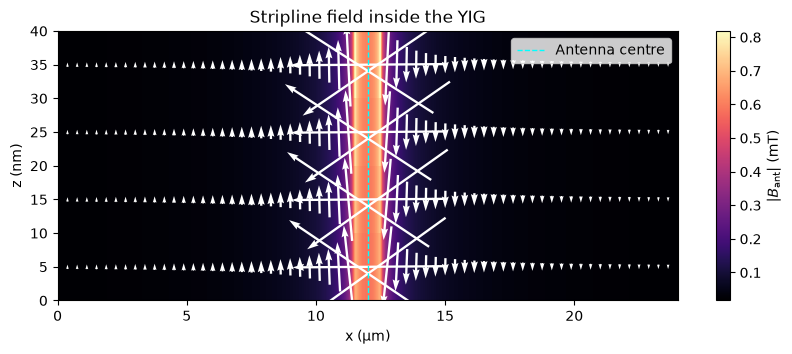

Antenna centre x: 12.000 µm
Drive current: 1.000 mA
Peak field in YIG: 0.819 mT
C:\Users\Artej\AppData\Local\Temp\ovftoolkit-yig-strip-38r1uppj\antenna-field.ovf


In [22]:
antenna_width = 1e-6
antenna_separation = 20e-9

# Offset from the geometric middle of the strip; positive values move toward +x.
antenna_x_offset = 0.0
strip_center_x = 0.5 * (x.min() + x.max())
antenna_x = strip_center_x + antenna_x_offset
relative_x = x - antenna_x

antenna_z = z.max() + (config["THICKNESS"] / config["NZ"]) / 2 + antenna_separation
d = z - antenna_z
x_minus = relative_x - antenna_width / 2
x_plus = relative_x + antenna_width / 2
prefactor_per_amp = mu_0 / (2 * np.pi * antenna_width)

bx_per_amp = prefactor_per_amp * (np.arctan(x_plus / d) - np.arctan(x_minus / d))
bz_per_amp = 0.5 * prefactor_per_amp * np.log(
    (d**2 + x_minus**2) / (d**2 + x_plus**2)
)

antenna_field_per_amp = np.stack(
    (bx_per_amp, np.zeros_like(bx_per_amp), bz_per_amp), axis=-1
)
antenna_field_per_amp *= geom_fill

antenna = ovf.VField()
antenna.data = antenna_field_per_amp.astype(np.float32)
antenna.header.copy_from(geometry.header)
antenna.header["Title"] = "Stripline field per ampere (T/A)"
antenna.header["Desc"] = (
    "B field per ampere from the Biot-Savart law; current along +y; "
    f"x centre {antenna_x:.9g} m"
)
antenna_file = work_dir / "antenna-field.ovf"
with ovf.writer(antenna_file) as destination:
    destination.write(antenna)

middle_y = config["NY"] // 2
xx = x[:, middle_y, :] * 1e6
zz = z[:, middle_y, :] * 1e9
drive_bx = bx_per_amp * antenna_drive_current
drive_bz = bz_per_amp * antenna_drive_current
magnitude_mt = np.hypot(drive_bx[:, middle_y, :], drive_bz[:, middle_y, :]) * 1e3

fig, ax = plt.subplots(figsize=(10, 3.5))
image = ax.pcolormesh(xx, zz, magnitude_mt, shading="nearest", cmap="magma")
stride = max(1, config["NX"] // 64)
ax.quiver(
    xx[:, ::stride], zz[:, ::stride],
    drive_bx[:, middle_y, ::stride], drive_bz[:, middle_y, ::stride],
    color="white", pivot="mid", scale=None,
)
ax.axvline(
    antenna_x * 1e6, color="cyan", linestyle="--", linewidth=1,
    label="Antenna centre",
)
ax.set(xlabel="x (µm)", ylabel="z (nm)", title="Stripline field inside the YIG")
ax.legend(loc="upper right")
fig.colorbar(image, ax=ax, label=r"$|B_\mathrm{ant}|$ (mT)")
plt.show()

print(f"Antenna centre x: {antenna_x * 1e6:.3f} µm")
print(f"Drive current: {antenna_drive_current * 1e3:.3f} mA")
print(
    f"Peak field in YIG: "
    f"{np.linalg.norm(antenna_field_per_amp, axis=-1).max() * abs(antenna_drive_current) * 1e3:.3f} mT"
)
print(antenna_file)

## Run the broadband simulation

The static field and equilibrium magnetization point along the antenna (`y`); the antenna's `x` and `z` field components are transverse. A sinc pulse excites up to 15 GHz. Both absorbing ends share region 1 and therefore the larger damping configured above.


In [24]:
dynamics_source = work_dir / "yig-strip-dynamics.mx3"
dynamics_out = work_dir / "dynamics.out"
antenna_for_mumax = antenna_file.resolve().as_posix()

dynamics_experiment = f"""
Bbias := {bias_field:.17g}
B_ext = Vector(0, Bbias, 0)
m = Uniform(0, 1, 0)
minimize()
SaveAs(m, "equilibrium.ovf")

fExc    := {f_exc:.17g}
fSample := {f_sample:.17g}
duration := {duration:.17g}
antennaCurrent := {antenna_drive_current:.17g}
antennaFieldPerAmp := LoadFile(\"{antenna_for_mumax}\")
B_ext.Add(antennaFieldPerAmp, antennaCurrent*sinc(2*pi*fExc*t - 32.3138))

TableAdd(B_ext)
TableAdd(E_total)
TableAutoSave(1/fSample)
AutoSave(m, 1/fSample)
run(duration - 1/(2*fSample))
"""

render_mumax(dynamics_experiment, dynamics_source)
subprocess.run([str(mumax3), "-o", str(dynamics_out), str(dynamics_source)], check=True)

snapshots = sorted(dynamics_out.glob("m*.ovf"))
expected = round(duration * f_sample)
if len(snapshots) != expected:
    raise RuntimeError(f"MuMax3 wrote {len(snapshots)} snapshots; expected {expected}")
print(f"Created {len(snapshots)} snapshots in {dynamics_out}")

Created 800 snapshots in C:\Users\Artej\AppData\Local\Temp\ovftoolkit-yig-strip-38r1uppj\dynamics.out


## Compare dejittered and raw timestamp spectra

MuMax3's adaptive time integration does not generally land exactly on every requested output time. The default transform interpolates snapshots onto a uniform time grid; `--no-reinterp` treats their nominally regular timestamps as exact. Comparing both RMS spectra makes the resulting high-frequency artifact visible.


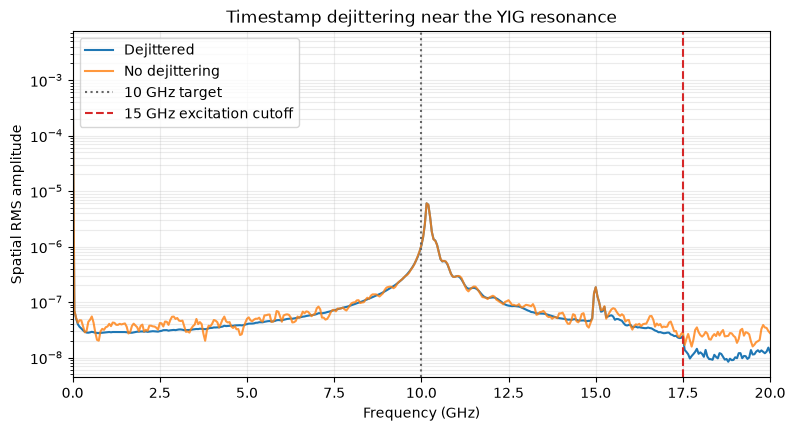

In [25]:
dejittered_file = work_dir / "spectrum-dejittered.ovf"
raw_file = work_dir / "spectrum-no-dejitter.ovf"

# MSVC's wildcard expansion avoids Windows' short command-line limit.
# POSIX subprocesses do not expand globs, but the short basenames fit easily.
snapshot_arguments = ["m*.ovf"] if os.name == "nt" else [p.name for p in snapshots]
common = [str(batchfft), *snapshot_arguments]
subprocess.run(
    [*common, "-o", str(dejittered_file)], cwd=dynamics_out, check=True
)
subprocess.run(
    [*common, "--no-reinterp", "-o", str(raw_file)],
    cwd=dynamics_out, check=True,
)

dejittered = ovf.eval_macroparams(dejittered_file, mask=geom_fill)
raw = ovf.eval_macroparams(raw_file, mask=geom_fill)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(dejittered.f / 1e9, dejittered.rms, label="Dejittered")
ax.semilogy(raw.f / 1e9, raw.rms, label="No dejittering", alpha=0.8)
ax.axvline(10, color="0.4", linestyle=":", label="10 GHz target")
ax.axvline(f_exc / 1e9, color="tab:red", linestyle="--", label="15 GHz excitation cutoff")
ax.set(xlim=(0, f_sample / 2e9), xlabel="Frequency (GHz)", ylabel="Spatial RMS amplitude",
       title="Timestamp dejittering near the YIG resonance")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()

## Transform the spectrum along the strip

For each temporal-frequency segment, the complex vector amplitude is weighted by geometry and averaged over $y$ (the antenna's length) and $z$ (the film thickness). The absorbing pads are cropped, a Hann window suppresses the crop-edge discontinuity, and a complex spatial FFT along $x$ produces $m(f,k_x)$. The plotted value is $\sqrt{|m_x|^2+|m_y|^2+|m_z|^2}$. The active interval is centered using the OVF coordinate range rather than assuming that its midpoint is zero. The static $f=0$ row is excluded from the decibel normalization so it cannot hide the dynamic branches.


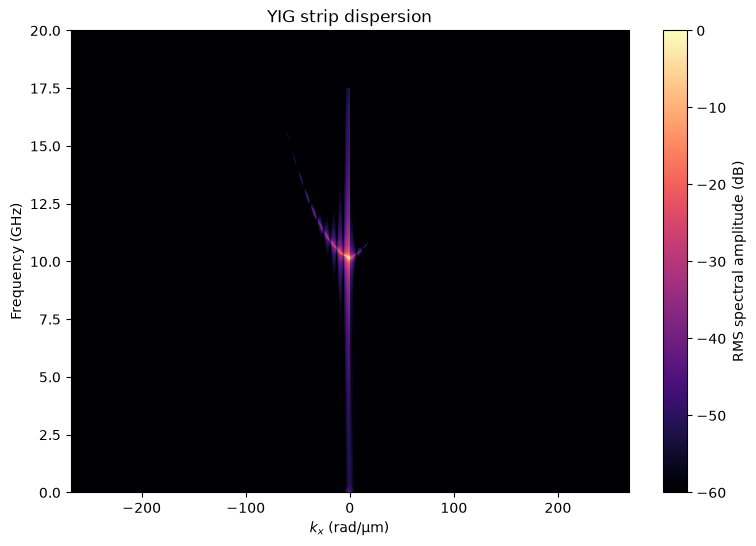

In [26]:
def dispersion_map(spectrum_file, geometry_mask, active_length):
    weights = np.asarray(geometry_mask)[..., 0]
    x_line = x[0, 0, :]
    strip_center_x = 0.5 * (x_line.min() + x_line.max())
    active = np.abs(x_line - strip_center_x) <= active_length / 2
    dx = float(np.median(np.diff(x_line)))
    kx = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(active.sum(), d=dx))
    window = np.hanning(active.sum())[:, None]

    with ovf.reader(spectrum_file) as spectrum:
        result = np.empty((len(spectrum), active.sum()), dtype=np.float64)
        frequencies = np.empty(len(spectrum), dtype=np.float64)
        pattern = re.compile(r"f\s*=\s*([^\s]+)\s*Hz")

        for row, field in enumerate(spectrum):
            values = field.complex_data
            line_weights = weights.sum(axis=(0, 1))
            line = np.divide(
                (values * weights[..., None]).sum(axis=(0, 1)),
                line_weights[:, None],
                out=np.zeros((values.shape[2], values.shape[3]), dtype=values.dtype),
                where=line_weights[:, None] > 0,
            )[active]
            transformed = np.fft.fftshift(
                np.fft.fft(line * window, axis=0, norm="ortho"), axes=0
            )
            result[row] = np.sqrt(np.sum(np.abs(transformed) ** 2, axis=1))
            match = pattern.search(field.header.get("desc", ""))
            if match is None:
                raise ValueError(f"Frequency missing from spectrum segment {row}")
            frequencies[row] = float(match.group(1))

    return frequencies, kx, result

frequencies, kx, rms_fk = dispersion_map(
    dejittered_file, geom_fill, config["ACTIVE_LENGTH"]
)

positive_frequency = frequencies > 0
dynamic_rms = rms_fk[positive_frequency]
dynamic_frequency = frequencies[positive_frequency]
reference = dynamic_rms.max()
if reference <= 0 or not np.isfinite(reference):
    raise ValueError("The positive-frequency dispersion contains no finite signal")

# The equilibrium magnetization produces a huge f=0, k=0 peak. Exclude that
# row from the normalization so the driven modes set the 0 dB reference.
floor = reference * 10 ** (-60 / 20)
dispersion_db = 20 * np.log10(np.maximum(dynamic_rms, floor) / reference)

fig, ax = plt.subplots(figsize=(9, 6))
image = ax.pcolormesh(
    kx * 1e-6,
    dynamic_frequency / 1e9,
    dispersion_db,
    shading="auto", cmap="magma", vmin=-60, vmax=0,
)
ax.set(xlabel=r"$k_x$ (rad/µm)", ylabel="Frequency (GHz)",
       ylim=(0, f_sample / 2e9), title="YIG strip dispersion")
fig.colorbar(image, ax=ax, label="RMS spectral amplitude (dB)")
plt.show()

## Clean up

The simulation produces hundreds of large OVF snapshots. Run this cell only after retaining any plots or files you want.


In [27]:
shutil.rmtree(work_dir)
print(f"Removed temporary workspace: {work_dir}")

Removed temporary workspace: C:\Users\Artej\AppData\Local\Temp\ovftoolkit-yig-strip-38r1uppj
